In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder,MinMaxScaler,StandardScaler,RobustScaler
from sklearn.preprocessing import PowerTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix,classification_report,
                            roc_auc_score,roc_curve,cohen_kappa_score)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier


import warnings
warnings.filterwarnings('ignore')

## Load the dataset

In [2]:
data = pd.read_csv('Churn_Modelling.csv')

In [3]:
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [8]:
for i in data:
    print(i,pd.DataFrame({'Count':data[i].value_counts()}))

RowNumber            Count
RowNumber       
1              1
6671           1
6664           1
6665           1
6666           1
...          ...
3334           1
3335           1
3336           1
3337           1
10000          1

[10000 rows x 1 columns]
CustomerId             Count
CustomerId       
15634602        1
15667932        1
15766185        1
15667632        1
15599024        1
...           ...
15599078        1
15702300        1
15660735        1
15671390        1
15628319        1

[10000 rows x 1 columns]
Surname           Count
Surname        
Smith        32
Scott        29
Martin       29
Walker       28
Brown        26
...         ...
Izmailov      1
Bold          1
Bonham        1
Poninski      1
Burbidge      1

[2932 rows x 1 columns]
CreditScore              Count
CreditScore       
850            233
678             63
655             54
705             53
667             53
...            ...
404              1
351              1
365              1
417       

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


## Descriptive Statistics

In [6]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,5.000500e+03,2886.895680,1.00,2500.75,5.000500e+03,7.500250e+03,10000.00
CustomerId,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
CreditScore,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00
Age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
Tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
Balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
NumOfProducts,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
HasCrCard,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
IsActiveMember,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
EstimatedSalary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48


In [7]:
data.describe(include='object').T

,count,unique,top,freq
Surname,10000,2932,Smith,32
Geography,10000,3,France,5014
Gender,10000,2,Male,5457


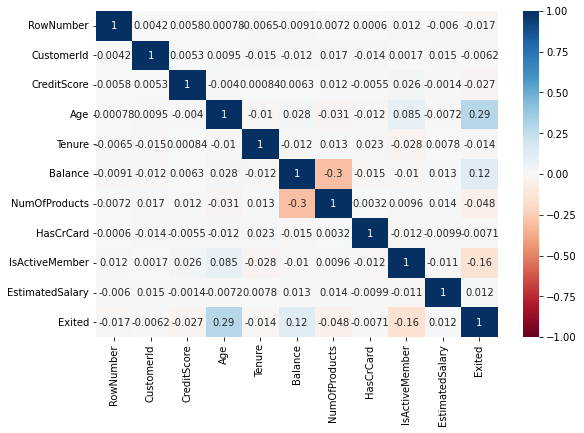

In [8]:
# Explore the correlation among numerical columns
plt.figure(figsize=(9,6))
sns.heatmap(data.corr(),vmin=-1,annot=True,cmap='RdBu')
plt.show()

## Univariate Analysis

In [9]:
data.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [10]:
num_cols = ['CreditScore','Age', 'Balance','EstimatedSalary']
cat_cols = ['Geography','Gender','NumOfProducts', 'HasCrCard',
       'IsActiveMember','Exited','Tenure']

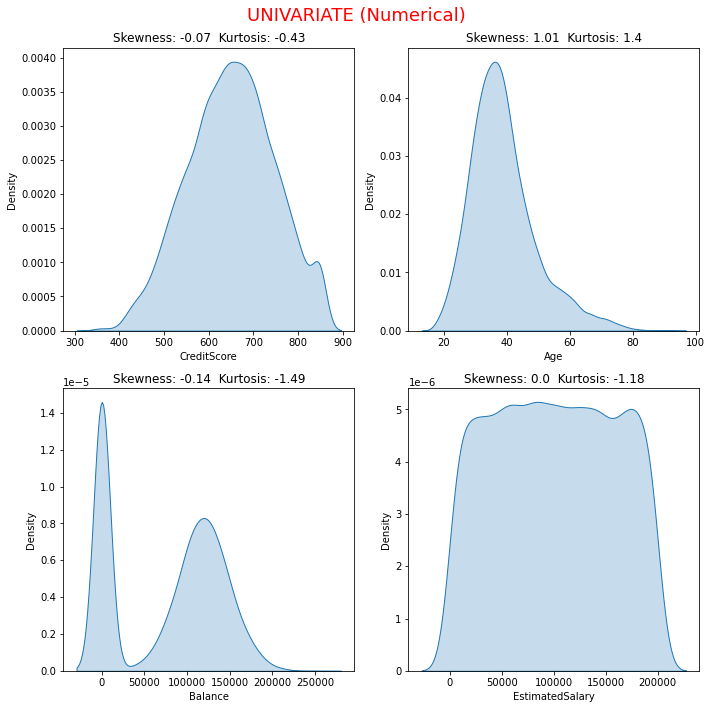

In [11]:
# Num Columns

# Explore the numrical columns

t=1
plt.figure(figsize=(10,10))
plt.suptitle('UNIVARIATE (Numerical)',color='red',size=18)
for i in num_cols:
    s,k = data[i].skew(),data[i].kurt()
    plt.subplot(2,2,t)
    sns.kdeplot(data=data,x=i,fill=True)
    plt.title(f'Skewness: {round(s,2)}  Kurtosis: {round(k,2)}')
    t+=1
plt.tight_layout()
plt.show()

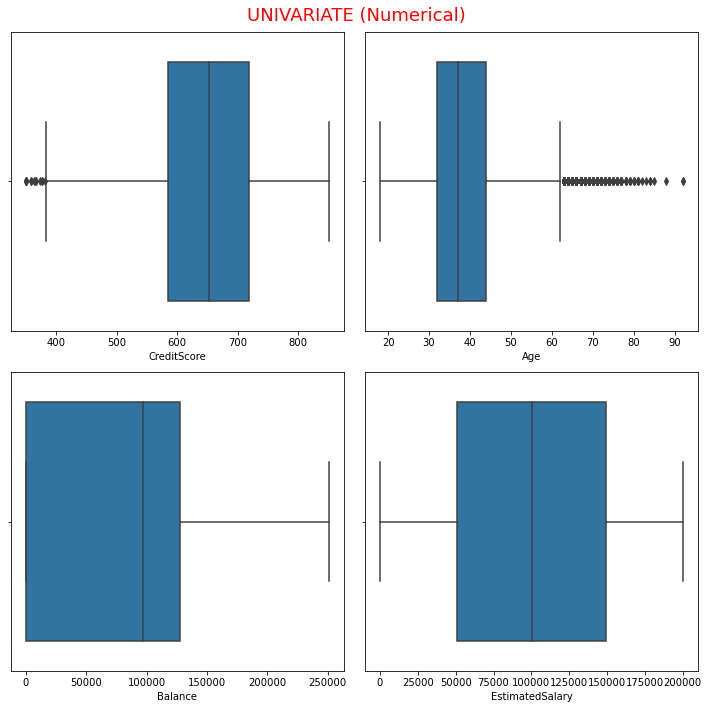

In [12]:
t=1
plt.figure(figsize=(10,10))
plt.suptitle('UNIVARIATE (Numerical)',color='red',size=18)
for i in num_cols:
    plt.subplot(2,2,t)
    sns.boxplot(data=data,x=i)
    t+=1
plt.tight_layout()
plt.show()

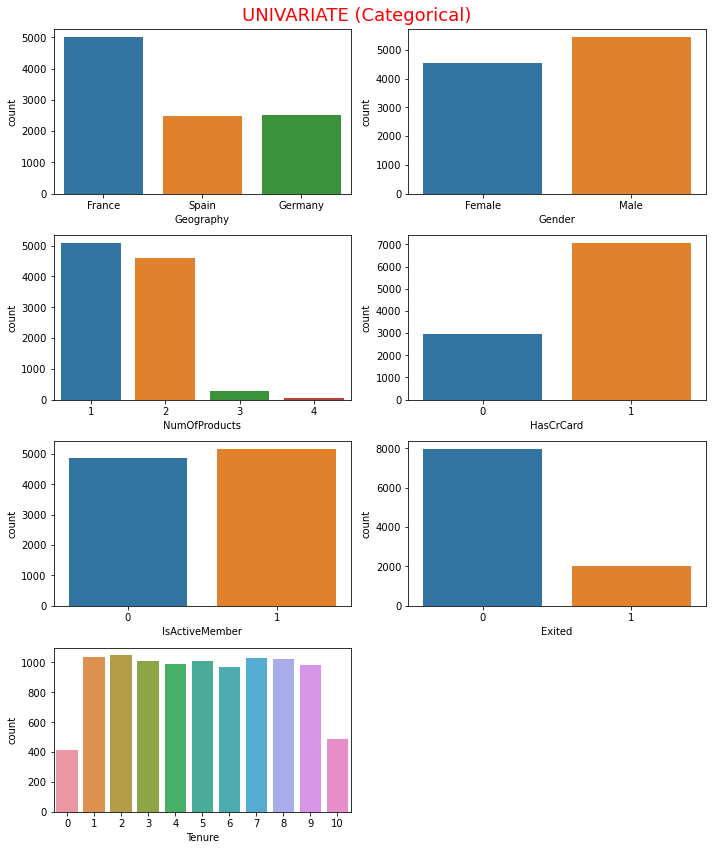

In [13]:
# Explore the Categorical columns

t=1
plt.figure(figsize=(10,12))
plt.suptitle('UNIVARIATE (Categorical)',color='red',size=18)
for i in cat_cols:
    plt.subplot(4,2,t)
    sns.countplot(data=data,x=i)
    t+=1
plt.tight_layout()
plt.show()

## Bivariate Analysis

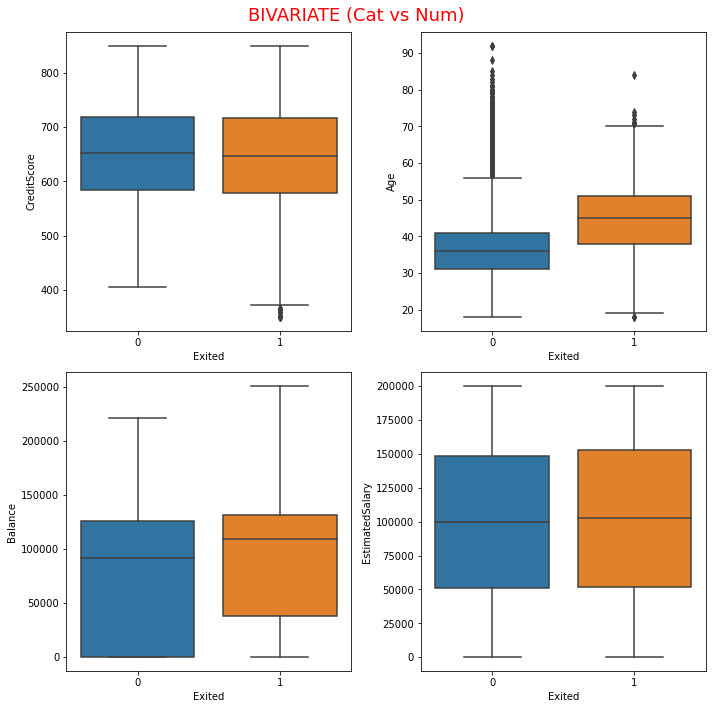

In [14]:
# Cat vs Num
t=1
plt.figure(figsize=(10,10))
plt.suptitle('BIVARIATE (Cat vs Num)',color='red',size=18)
for i in num_cols:
    plt.subplot(2,2,t)
    sns.boxplot(data=data,y=i,x='Exited')
    t+=1
plt.tight_layout()
plt.show()

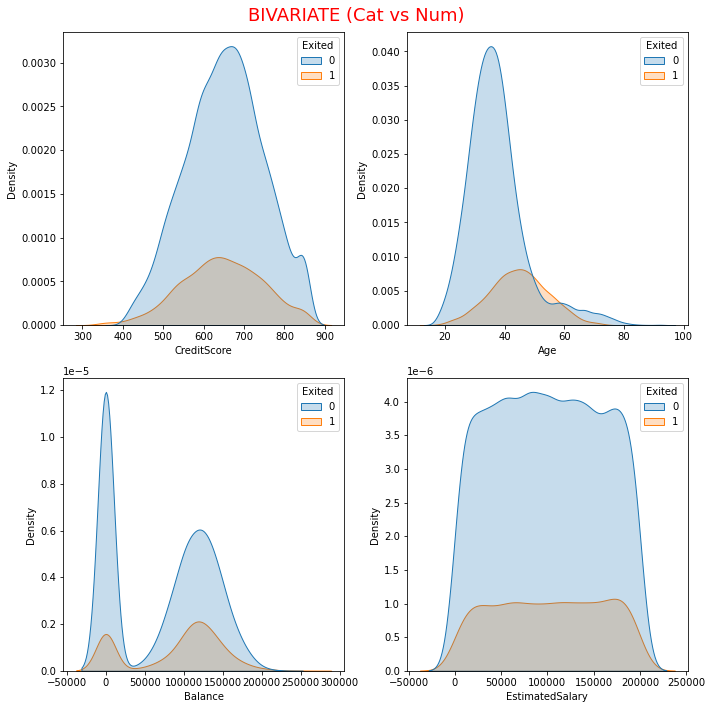

In [15]:
# Cat vs Num
t=1
plt.figure(figsize=(10,10))
plt.suptitle('BIVARIATE (Cat vs Num)',color='red',size=18)
for i in num_cols:
    plt.subplot(2,2,t)
    sns.kdeplot(data=data,x=i,hue='Exited',fill=True)
    t+=1
plt.tight_layout()
plt.show()

<Figure size 720x720 with 0 Axes>

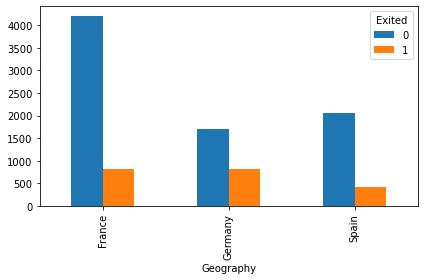

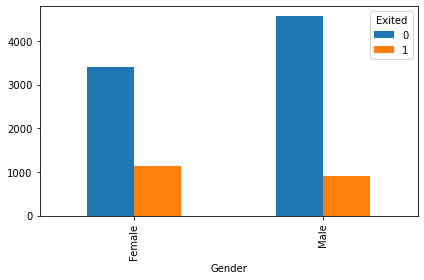

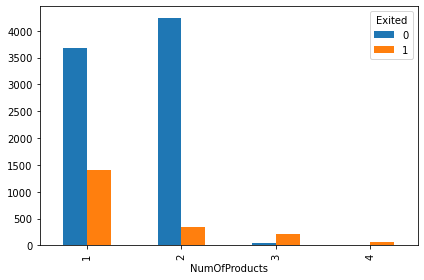

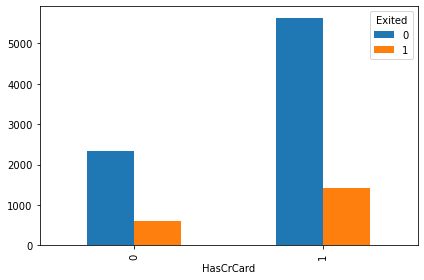

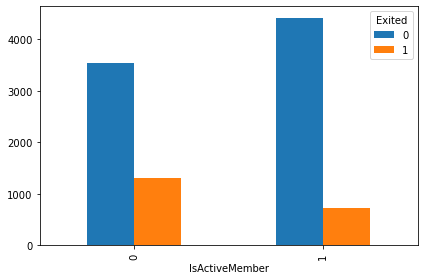

<Figure size 432x288 with 0 Axes>

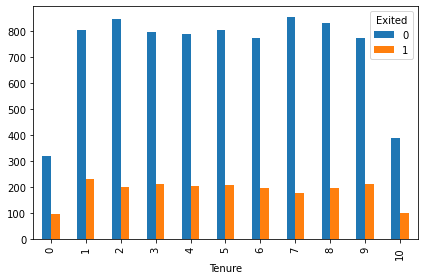

In [16]:
# cat vs cat

plt.figure(figsize=(10,10))
for i in cat_cols:
    if i != 'Exited':
        pd.crosstab(data[i],data['Exited']).plot(kind='bar')
    plt.tight_layout()
    plt.show()
        

## Multivaraite Analysis

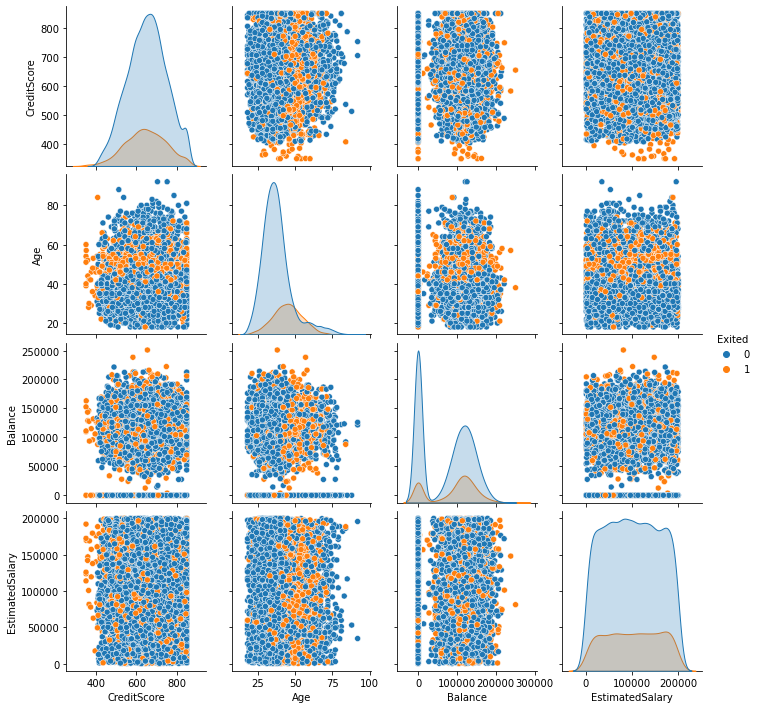

In [17]:
sns.pairplot(data=data,x_vars=num_cols,y_vars=num_cols,hue='Exited')
plt.show()

## Data Preprocessing

In [18]:
# Remove the redundant columns
data.head(2)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0


In [19]:
data.drop(columns=['RowNumber', 'Surname'],inplace=True)

In [20]:
data.set_index('CustomerId',inplace=True)

In [21]:
data.head(2)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
CustomerId,,,,,,,,,,,
15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0


### Missing Value Treatment

In [22]:
data.isnull().sum()

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

### Train Test Split

In [24]:
y = data['Exited']
x = data.drop(columns='Exited')

In [26]:
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.8,stratify=y,
                                                random_state=1)

In [27]:
print(x_train.shape,y_train.shape,x_test.shape,y_test.shape)

(8000, 10) (8000,) (2000, 10) (2000,)


### Outlier Treatment

In [28]:
num_cols

['CreditScore', 'Age', 'Balance', 'EstimatedSalary']

In [29]:
# Cap the outliers using IQR method
for i in num_cols:
    q3,q1 = x_train[i].quantile([0.75,0.25])
    iqr = q3-q1
    ul,ll = q3+1.5*iqr,q1-1.5*iqr
    x_train[i] = x_train[i].apply(lambda x: ul if x>ul else ll if x<ll else x)

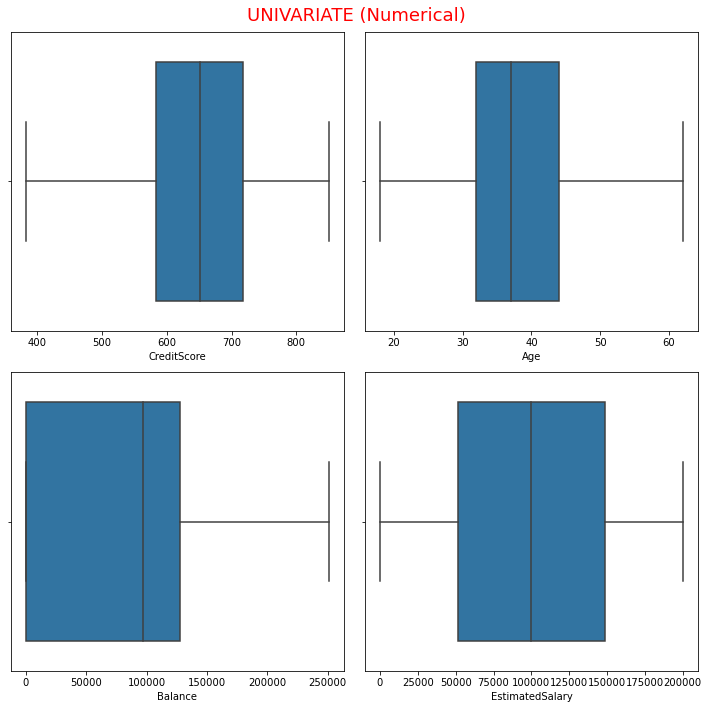

In [32]:
t=1
plt.figure(figsize=(10,10))
plt.suptitle('UNIVARIATE (Numerical)',color='red',size=18)
for i in num_cols:
    plt.subplot(2,2,t)
    sns.boxplot(data=x_train,x=i)
    t+=1
plt.tight_layout()
plt.show()

### Duplicates

In [33]:
x_train.duplicated().sum()

0

## Feature Engineering

### Encoding

In [34]:
x_train.head(3)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
CustomerId,,,,,,,,,,
15578462,596.0,Spain,Female,62.0,9,134208.25,1,1,1,13455.43
15747974,614.0,France,Male,49.0,1,0.00,2,1,0,192440.54
15727299,445.0,Spain,Male,62.0,1,64119.38,1,1,1,76569.64


In [38]:
map_dic = round(x_train['Geography'].value_counts(normalize=True),4).to_dict()
map_dic

{'France': 0.5008, 'Germany': 0.2505, 'Spain': 0.2488}

In [39]:
x_train['Geography'] = x_train['Geography'].map(map_dic)
x_test['Geography'] = x_test['Geography'].map(map_dic)

In [40]:
x_train.head(3)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
CustomerId,,,,,,,,,,
15578462,596.0,0.2488,Female,62.0,9,134208.25,1,1,1,13455.43
15747974,614.0,0.5008,Male,49.0,1,0.00,2,1,0,192440.54
15727299,445.0,0.2488,Male,62.0,1,64119.38,1,1,1,76569.64


In [41]:
x_test.head(3)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
CustomerId,,,,,,,,,,
15595160,413,0.2488,Male,35,2,0.00,2,1,1,60972.84
15572792,535,0.2488,Male,35,8,118989.92,1,1,1,135536.72
15797692,659,0.5008,Female,33,7,89939.62,1,1,0,136540.09


In [42]:
x_train = pd.get_dummies(x_train,columns=['Gender'],drop_first=True,dtype=int)
x_test = pd.get_dummies(x_test,columns=['Gender'],drop_first=True,dtype=int)

In [53]:
x_train_s.head(2)

,CreditScore,Geography,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Gender_Male
CustomerId,,,,,,,,,,
15578462,-0.557541,0.2488,2.382989,9,0.925750,1,1,1,-1.505216,0
15747974,-0.371218,0.5008,1.056207,1,-1.219862,2,1,0,1.614655,1


In [44]:
x_test.head(2)

,CreditScore,Geography,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Gender_Male
CustomerId,,,,,,,,,,
15595160,413,0.2488,35,2,0.00,2,1,1,60972.84,1
15572792,535,0.2488,35,8,118989.92,1,1,1,135536.72,1


### Feature Scalling

In [47]:
x_train_s = x_train.copy()
x_test_s = x_test.copy()

In [48]:
# Use Standard Scaler to scale the numeric columns
scaler = StandardScaler()
x_train_s[num_cols] = scaler.fit_transform(x_train_s[num_cols])
x_test_s[num_cols] = scaler.transform(x_test_s[num_cols])

In [52]:
x_test.head(2)

,CreditScore,Geography,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Gender_Male
CustomerId,,,,,,,,,,
15595160,413,0.2488,35,2,0.00,2,1,1,60972.84,1
15572792,535,0.2488,35,8,118989.92,1,1,1,135536.72,1


In [32]:
data.head(3)

,CreditScore,Geography,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Gender_Male
CustomerId,,,,,,,,,,,
15634602,-0.326878,0.16,0.342615,2,-1.225848,1,1,1,0.021886,1,0
15647311,-0.440804,0.17,0.240011,1,0.117350,1,0,1,0.216534,0,0
15619304,-1.538636,0.16,0.342615,8,1.333053,3,1,0,0.240687,1,0


## Predictive Modelling

In [202]:
model_lr = LogisticRegression(class_weight={0:cw_0,1:cw_1})

In [203]:
model_lr.fit(x_train,y_train)

LogisticRegression(class_weight={0: 0.6279434850863422, 1: 2.4539877300613497})

In [204]:
pred_lr_s = model_lr.predict_proba(x_test)[:,1]
pred_lr_h = (pred_lr_s>0.541103).astype(int)

In [205]:
print(confusion_matrix(y_test,pred_lr_h))

[[1178  415]
 [ 167  240]]


In [206]:
print(classification_report(y_test,pred_lr_h))

              precision    recall  f1-score   support

           0       0.88      0.74      0.80      1593
           1       0.37      0.59      0.45       407

    accuracy                           0.71      2000
   macro avg       0.62      0.66      0.63      2000
weighted avg       0.77      0.71      0.73      2000



In [207]:
print(cohen_kappa_score(y_test,pred_lr_h))

0.26830648152222425


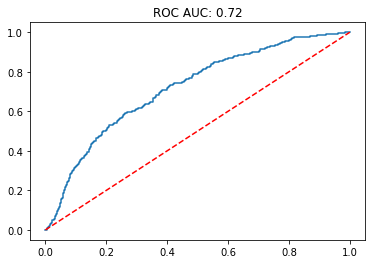

In [208]:
# ROC Curve
fpr,tpr,thres = roc_curve(y_test,pred_lr_s)
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1],color='red',ls='--')
plt.title(f'ROC AUC: {round(roc_auc_score(y_test,pred_lr_s),2)}')
plt.show()

In [209]:
pd.DataFrame({'FPR':fpr,'TPR':tpr,'Thesholds':thres,
              'Yodens Index':tpr*(1-fpr)}).sort_values(by='Yodens Index',
                                                       ascending=False)

,FPR,TPR,Thesholds,Yodens Index
307,0.260515,0.589681,0.541103,0.436060
311,0.266792,0.594595,0.538320,0.435961
377,0.384181,0.707617,0.481003,0.435764
309,0.264909,0.592138,0.538919,0.435275
371,0.376648,0.697789,0.485183,0.434968
...,...,...,...,...
4,0.005022,0.004914,0.898320,0.004889
0,0.000000,0.000000,inf,0.000000
1,0.000628,0.000000,0.937043,0.000000
2,0.004394,0.000000,0.903240,0.000000


One possible of the above scores could be class Imbalance. We have more data in class 0 and less data in class 1. More data means better learning.

We can use

* class weights
* Oversampling / Undersampling

In [98]:
cw_0 = len(y_train)/(2*y_train.value_counts()[0])

In [99]:
cw_1 = len(y_train)/(2*y_train.value_counts()[1])

### Sampling to treat class imbalance

In [210]:
# pip install imblearn
from imblearn.over_sampling import RandomOverSampler,SMOTE
from imblearn.under_sampling import RandomUnderSampler

In [211]:
y_train.value_counts(normalize=True)

0    0.79625
1    0.20375
Name: Exited, dtype: float64

In [212]:
sampler = SMOTE(sampling_strategy=0.7)
x_train_os,y_train_os = sampler.fit_resample(x_train,y_train)

In [213]:
y_train_os.value_counts(normalize=True)

0    0.588235
1    0.411765
Name: Exited, dtype: float64

In [214]:
x_train_os.duplicated().sum()

0

In [215]:
# Re fit the Logistic regression with oversampled data

model_lr = LogisticRegression()

In [216]:
model_lr.fit(x_train_os,y_train_os)

LogisticRegression()

In [217]:
pred_lr_s = model_lr.predict_proba(x_test)[:,1]
pred_lr_h = (pred_lr_s>0.5).astype(int)

In [218]:
print(confusion_matrix(y_test,pred_lr_h))

[[1268  325]
 [ 201  206]]


In [219]:
print(classification_report(y_test,pred_lr_h))

              precision    recall  f1-score   support

           0       0.86      0.80      0.83      1593
           1       0.39      0.51      0.44       407

    accuracy                           0.74      2000
   macro avg       0.63      0.65      0.63      2000
weighted avg       0.77      0.74      0.75      2000



In [220]:
print(cohen_kappa_score(y_test,pred_lr_h))

0.27135006642350634


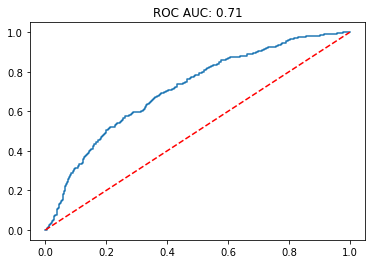

In [221]:
# ROC Curve
fpr,tpr,thres = roc_curve(y_test,pred_lr_s)
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1],color='red',ls='--')
plt.title(f'ROC AUC: {round(roc_auc_score(y_test,pred_lr_s),2)}')
plt.show()

In [193]:
pd.DataFrame({'FPR':fpr,'TPR':tpr,'Thesholds':thres,
              'Yodens Index':tpr*(1-fpr)}).sort_values(by='Yodens Index',
                                                       ascending=False)

,FPR,TPR,Thesholds,Yodens Index
353,0.357188,0.673219,0.403857,0.432753
351,0.356560,0.670762,0.404746,0.431595
352,0.357188,0.670762,0.403937,0.431174
349,0.355304,0.668305,0.405802,0.430853
347,0.354049,0.665848,0.406176,0.430105
...,...,...,...,...
4,0.005022,0.007371,0.882412,0.007334
0,0.000000,0.000000,inf,0.000000
1,0.000628,0.000000,0.932596,0.000000
2,0.003766,0.000000,0.893698,0.000000


## KNN (K-Nearest Neighbours)

In [288]:
model_knn = KNeighborsClassifier(n_neighbors=11,weights='distance')

In [289]:
x_train_s.head(2)

,CreditScore,Geography,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Gender_Male
CustomerId,,,,,,,,,,
15578462,-0.557541,0.2488,2.382989,9,0.925750,1,1,1,-1.505216,0
15747974,-0.371218,0.5008,1.056207,1,-1.219862,2,1,0,1.614655,1


In [290]:
# Scale The train set
x_train_s_os = x_train_os.copy()
x_train_s_os[num_cols] = scaler.transform(x_train_os[num_cols])

In [291]:
model_knn.fit(x_train_s_os,y_train_os)  # Always pass scaled data

KNeighborsClassifier(n_neighbors=11, weights='distance')

In [292]:
pred_knn_s = model_knn.predict_proba(x_test_s)[:,1] # Scaled data
pred_knn_h = (pred_knn_s>0.5).astype(int)

In [293]:
print(confusion_matrix(y_test,pred_knn_h))

[[1311  282]
 [ 173  234]]


In [294]:
print(classification_report(y_test,pred_knn_h))

              precision    recall  f1-score   support

           0       0.88      0.82      0.85      1593
           1       0.45      0.57      0.51       407

    accuracy                           0.77      2000
   macro avg       0.67      0.70      0.68      2000
weighted avg       0.80      0.77      0.78      2000



In [295]:
print(cohen_kappa_score(y_test,pred_knn_h))

0.36184059198752294


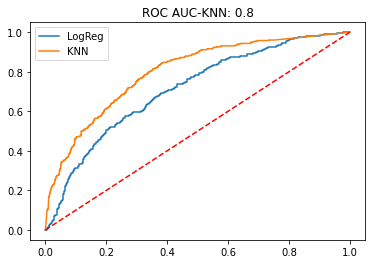

In [296]:
# ROC Curve
fpr,tpr,thres = roc_curve(y_test,pred_lr_s)
fpr_knn,tpr_knn,thres_knn = roc_curve(y_test,pred_knn_s)
plt.plot(fpr,tpr,label='LogReg')
plt.plot(fpr_knn,tpr_knn,label='KNN')
plt.plot([0,1],[0,1],color='red',ls='--')
plt.title(f'ROC AUC-KNN: {round(roc_auc_score(y_test,pred_knn_s),2)}')
plt.legend()
plt.show()

## Naive Bayes

In [297]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB

In [310]:
model_nb = GaussianNB()

In [314]:
model_nb.fit(x_train_s,y_train)

GaussianNB()

In [348]:
pred_nb_s = model_nb.predict_proba(x_test_s)[:,1]
pred_nb_h = (pred_nb_s>0.35).astype(int)

In [349]:
print(classification_report(y_test,pred_nb_h))

              precision    recall  f1-score   support

           0       0.87      0.90      0.89      1593
           1       0.56      0.48      0.51       407

    accuracy                           0.82      2000
   macro avg       0.71      0.69      0.70      2000
weighted avg       0.81      0.82      0.81      2000



In [350]:
print(cohen_kappa_score(y_test,pred_nb_h))

0.4006094889381504


In [351]:
print(roc_auc_score(y_test,pred_nb_s))

0.8014069539493268


In [352]:
print(roc_auc_score(y_test,pred_knn_s))

0.7984301713115273
